In [1]:
import cv2
import numpy as np
import pandas as pd
import pickle

In [3]:
import pickle

vehicle_positions_path = r"C:\Users\DELL\vehicle_positions.pkl"

with open(vehicle_positions_path, "rb") as f:
    vehicle_positions = pickle.load(f)

print("Tracked vehicles:", len(vehicle_positions))

Tracked vehicles: 89


In [5]:
import cv2

video_path = r"C:\Users\DELL\OneDrive\Desktop\Final\Trafficvedio.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)

cap.release()

print("FPS:", fps)

FPS: 23.976023976023978


In [6]:
import numpy as np

vehicle_movement = {}

for vehicle_id, positions in vehicle_positions.items():

    # Need at least 2 positions
    if len(positions) < 2:
        continue

    total_pixel_distance = 0

    for i in range(1, len(positions)):

        frame1, x1, y1 = positions[i - 1]
        frame2, x2, y2 = positions[i]

        # Distance moved between two frames
        distance = np.sqrt(
            (x2 - x1)**2 +
            (y2 - y1)**2
        )

        total_pixel_distance += distance

    # Time between first and last observation
    first_frame = positions[0][0]
    last_frame = positions[-1][0]

    time_seconds = (last_frame - first_frame) / fps

    if time_seconds > 0:

        vehicle_movement[vehicle_id] = {
            "pixel_distance": total_pixel_distance,
            "time_seconds": time_seconds
        }

print("Vehicles with movement data:", len(vehicle_movement))

Vehicles with movement data: 89


In [7]:
for vehicle_id, data in list(vehicle_movement.items())[:5]:

    print(
        "Vehicle:", vehicle_id,
        "| Distance:", round(data["pixel_distance"], 2),
        "pixels | Time:", round(data["time_seconds"], 2),
        "seconds"
    )

Vehicle: 101 | Distance: 475.21 pixels | Time: 3.04 seconds
Vehicle: 102 | Distance: 82.34 pixels | Time: 0.38 seconds
Vehicle: 103 | Distance: 168.56 pixels | Time: 1.46 seconds
Vehicle: 104 | Distance: 34.4 pixels | Time: 0.33 seconds
Vehicle: 105 | Distance: 719.68 pixels | Time: 8.93 seconds


In [8]:
vehicle_pixel_speeds = {}

for vehicle_id, data in vehicle_movement.items():

    pixel_distance = data["pixel_distance"]
    time_seconds = data["time_seconds"]

    pixel_speed = pixel_distance / time_seconds

    vehicle_pixel_speeds[vehicle_id] = pixel_speed


print("Vehicles with speed data:", len(vehicle_pixel_speeds))

Vehicles with speed data: 89


In [9]:
for vehicle_id, speed in list(vehicle_pixel_speeds.items())[:10]:

    print(
        "Vehicle:", vehicle_id,
        "| Pixel Speed:",
        round(speed, 2),
        "pixels/sec"
    )

Vehicle: 101 | Pixel Speed: 156.08 pixels/sec
Vehicle: 102 | Pixel Speed: 219.36 pixels/sec
Vehicle: 103 | Pixel Speed: 115.47 pixels/sec
Vehicle: 104 | Pixel Speed: 103.09 pixels/sec
Vehicle: 105 | Pixel Speed: 80.63 pixels/sec
Vehicle: 108 | Pixel Speed: 121.62 pixels/sec
Vehicle: 109 | Pixel Speed: 182.83 pixels/sec
Vehicle: 98 | Pixel Speed: 170.25 pixels/sec
Vehicle: 73 | Pixel Speed: 237.26 pixels/sec
Vehicle: 112 | Pixel Speed: 218.82 pixels/sec


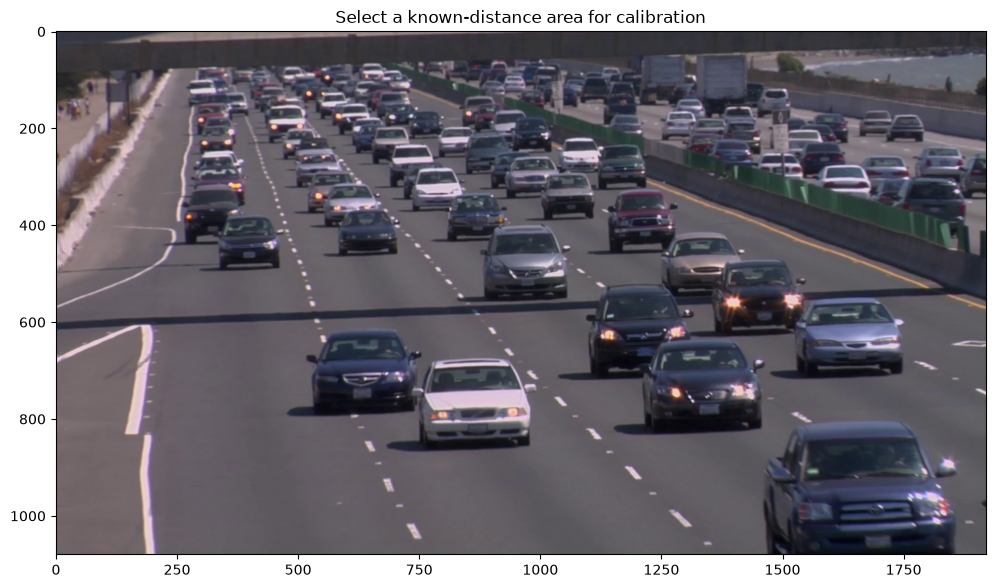

In [10]:
import cv2
import matplotlib.pyplot as plt

video_path = r"C:\Users\DELL\OneDrive\Desktop\Final\Trafficvedio.mp4"

cap = cv2.VideoCapture(video_path)

# Take a frame from the middle of the video
frame_number = 330
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)

ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 7))
    plt.imshow(frame_rgb)
    plt.title("Select a known-distance area for calibration")
    plt.axis("on")
    plt.show()
else:
    print("Could not read video frame")

In [11]:
import pandas as pd
import numpy as np

speed_df = pd.DataFrame(
    [
        {
            "Vehicle_ID": vehicle_id,
            "Pixel_Distance": data["pixel_distance"],
            "Time_Seconds": data["time_seconds"],
            "Pixel_Speed": vehicle_pixel_speeds[vehicle_id]
        }
        for vehicle_id, data in vehicle_movement.items()
        if vehicle_id in vehicle_pixel_speeds
    ]
)

print("Speed records:", len(speed_df))
display(speed_df.head(10))

Speed records: 89


,Vehicle_ID,Pixel_Distance,Time_Seconds,Pixel_Speed
0,101,475.207062,3.044708,156.076385
1,102,82.341614,0.375375,219.358276
2,103,168.557846,1.459792,115.467056
3,104,34.397434,0.333667,103.089218
4,105,719.677002,8.925583,80.630814
5,108,1354.417725,11.136125,121.623795
6,109,671.040039,3.670333,182.828094
7,98,1143.250610,6.715042,170.252197
8,73,376.034180,1.584917,237.258011
9,112,903.538696,4.129125,218.820862


In [12]:
print("Speed Statistics")
print("----------------")

print("Minimum Pixel Speed :",
      round(speed_df["Pixel_Speed"].min(), 2),
      "pixels/sec")

print("Maximum Pixel Speed :",
      round(speed_df["Pixel_Speed"].max(), 2),
      "pixels/sec")

print("Average Pixel Speed :",
      round(speed_df["Pixel_Speed"].mean(), 2),
      "pixels/sec")

Speed Statistics
----------------
Minimum Pixel Speed : 35.06 pixels/sec
Maximum Pixel Speed : 280.82 pixels/sec
Average Pixel Speed : 127.66 pixels/sec


In [13]:
q1 = speed_df["Pixel_Speed"].quantile(0.05)
q99 = speed_df["Pixel_Speed"].quantile(0.95)

speed_df_clean = speed_df[
    (speed_df["Pixel_Speed"] >= q1) &
    (speed_df["Pixel_Speed"] <= q99)
].copy()

print("Original records:", len(speed_df))
print("After filtering:", len(speed_df_clean))

Original records: 89
After filtering: 79


In [14]:
REAL_DISTANCE_METERS = 10

REFERENCE_PIXEL_DISTANCE = 200   # CHANGE this after measuring your video

meters_per_pixel = (
    REAL_DISTANCE_METERS /
    REFERENCE_PIXEL_DISTANCE
)

print("Meters per pixel:", meters_per_pixel)

Meters per pixel: 0.05


In [15]:
speed_df_clean["Speed_mps"] = (
    speed_df_clean["Pixel_Speed"] *
    meters_per_pixel
)

speed_df_clean["Speed_kmh"] = (
    speed_df_clean["Speed_mps"] * 3.6
)

display(
    speed_df_clean[
        ["Vehicle_ID", "Pixel_Speed", "Speed_kmh"]
    ].head(10)
)

,Vehicle_ID,Pixel_Speed,Speed_kmh
0,101,156.076385,28.093748
2,103,115.467056,20.784071
3,104,103.089218,18.556059
4,105,80.630814,14.513547
5,108,121.623795,21.892282
6,109,182.828094,32.909058
7,98,170.252197,30.645397
10,113,179.529617,32.315331
13,116,110.808334,19.945499
14,118,137.680695,24.782524


In [16]:
average_speed = speed_df_clean["Speed_kmh"].mean()

print(
    "Average Vehicle Speed:",
    round(average_speed, 2),
    "km/h"
)

Average Vehicle Speed: 22.5 km/h


In [17]:
vehicle_count = len(vehicle_positions)

print("Total Vehicles Tracked:", vehicle_count)


Total Vehicles Tracked: 89


In [18]:
final_yolo_output = {
    "Vehicle_Count": vehicle_count,
    "Average_Speed_kmh": round(average_speed, 2)
}

print("YOLO Traffic Output")
print("-------------------")
print("Vehicle Count       :", final_yolo_output["Vehicle_Count"])
print("Average Speed       :", final_yolo_output["Average_Speed_kmh"], "km/h")

YOLO Traffic Output
-------------------
Vehicle Count       : 89
Average Speed       : 22.5 km/h


In [19]:
speed_df_clean.to_csv(
    "vehicle_speed_results.csv",
    index=False
)

print("Saved: vehicle_speed_results.csv")

Saved: vehicle_speed_results.csv


In [20]:
final_df = pd.DataFrame([{
    "Vehicle_Count": vehicle_count,
    "Average_Speed_kmh": round(average_speed, 2)
}])

final_df.to_csv(
    "yolo_traffic_output.csv",
    index=False
)

print("Saved: yolo_traffic_output.csv")
display(final_df)

Saved: yolo_traffic_output.csv


,Vehicle_Count,Average_Speed_kmh
0,89,22.5


In [22]:
import pickle

with open("vehicle_speed_data.pkl", "wb") as f:
    pickle.dump(
        {
            "vehicle_positions": vehicle_positions,
            "vehicle_count": vehicle_count,
            "average_speed": average_speed,
            "speed_data": speed_df_clean
        },
        f
    )

print("Saved: vehicle_speed_data.pkl")


Saved: vehicle_speed_data.pkl
